In [1]:
!python -V

Python 3.10.20


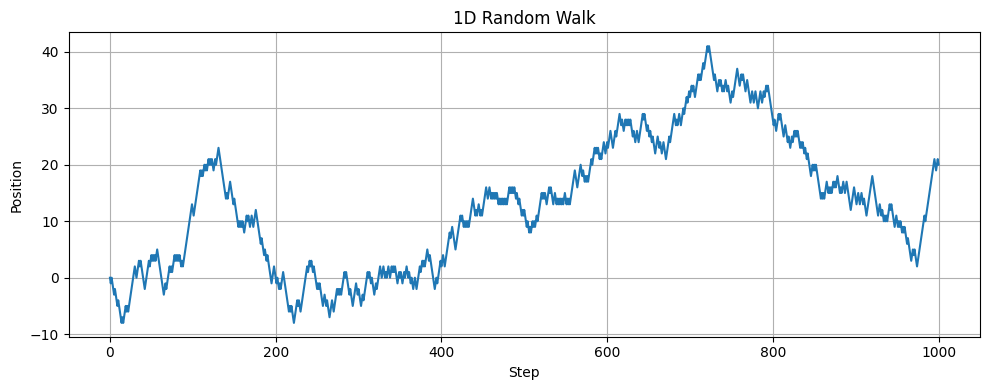

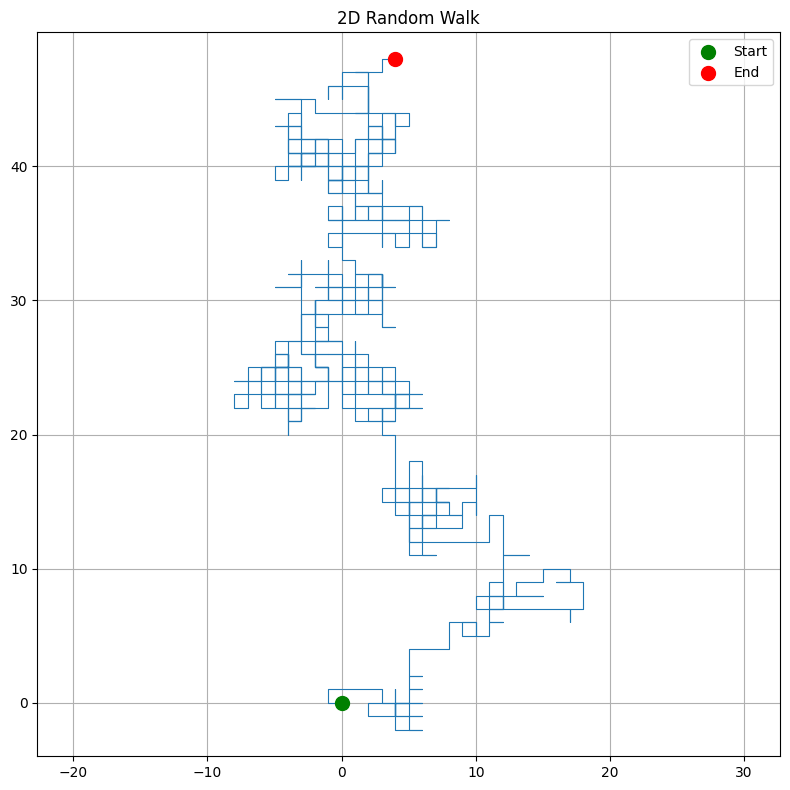

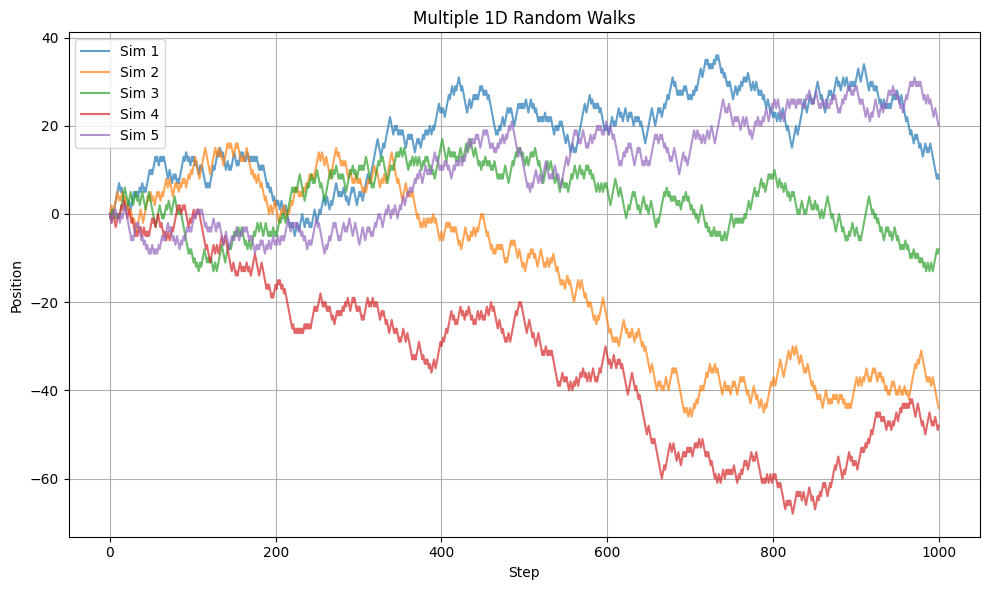

模拟次数: 2000
平均终点: 0.7870 (理论值: 0)
终点标准差: 31.3605 (理论值: sqrt(N) = 31.6228)


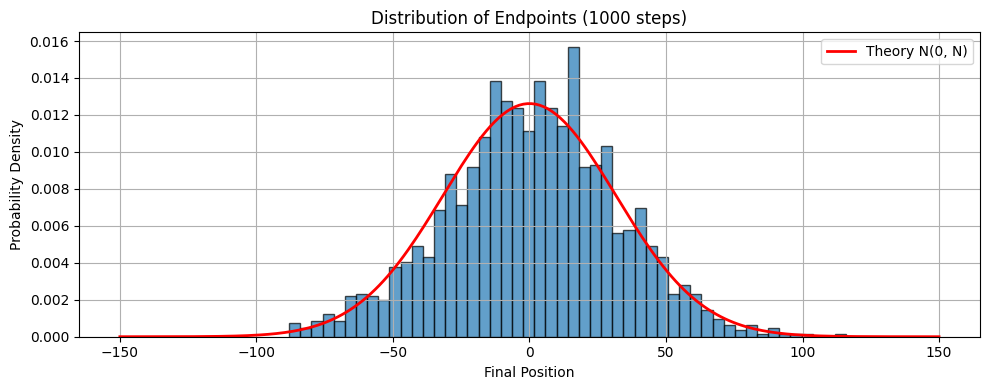

In [3]:
import numpy as np
import matplotlib.pyplot as plt

class RandomWalk:
    def __init__(self, n_steps=1000, dim=2, seed=None):
        self.n_steps = n_steps
        self.dim = dim
        if seed is not None:
            np.random.seed(seed)
    
    def walk_1d(self):
        """一维随机漫步"""
        steps = np.random.choice([-1, 1], size=self.n_steps)
        return np.concatenate([[0], np.cumsum(steps)])
    
    def walk_2d(self):
        """二维随机漫步（四方向）"""
        directions = np.array([[1,0], [-1,0], [0,1], [0,-1]])
        choices = np.random.randint(0, 4, self.n_steps)
        steps = directions[choices]
        path = np.cumsum(steps, axis=0)
        return np.vstack([[0,0], path])
    
    def walk_2d_gaussian(self, step_size=1.0):
        """二维高斯随机漫步（任意方向）"""
        angles = np.random.uniform(0, 2*np.pi, self.n_steps)
        steps = np.column_stack([
            step_size * np.cos(angles),
            step_size * np.sin(angles)
        ])
        path = np.cumsum(steps, axis=0)
        return np.vstack([[0,0], path])
    
    def statistics(self, n_simulations=1000):
        """统计终点位移的分布（验证扩散规律）"""
        endpoints = []
        for _ in range(n_simulations):
            path = self.walk_1d()
            endpoints.append(path[-1])
        endpoints = np.array(endpoints)
        
        print(f"模拟次数: {n_simulations}")
        print(f"平均终点: {endpoints.mean():.4f} (理论值: 0)")
        print(f"终点标准差: {endpoints.std():.4f} "
              f"(理论值: sqrt(N) = {np.sqrt(self.n_steps):.4f})")
        return endpoints


# ============ 使用示例 ============
rw = RandomWalk(n_steps=1000, seed=42)

# 1. 一维漫步
walk1d = rw.walk_1d()
plt.figure(figsize=(10, 4))
plt.plot(walk1d)
plt.title("1D Random Walk")
plt.xlabel("Step")
plt.ylabel("Position")
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. 二维漫步
path = rw.walk_2d()
plt.figure(figsize=(8, 8))
plt.plot(path[:, 0], path[:, 1], lw=0.8)
plt.scatter(0, 0, c='green', s=100, label='Start', zorder=5)
plt.scatter(path[-1, 0], path[-1, 1], c='red', s=100, label='End', zorder=5)
plt.title("2D Random Walk")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()

# 3. 多次模拟对比
plt.figure(figsize=(10, 6))
for i in range(5):
    np.random.seed(i)
    w = RandomWalk(n_steps=1000).walk_1d()
    plt.plot(w, alpha=0.7, label=f'Sim {i+1}')
plt.title("Multiple 1D Random Walks")
plt.xlabel("Step")
plt.ylabel("Position")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. 统计验证
endpoints = rw.statistics(n_simulations=2000)

plt.figure(figsize=(10, 4))
plt.hist(endpoints, bins=50, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(-150, 150, 200)
# 理论正态分布
sigma = np.sqrt(1000)
plt.plot(x, np.exp(-x**2/(2*sigma**2))/(sigma*np.sqrt(2*np.pi)), 
         'r-', lw=2, label='Theory N(0, N)')
plt.title("Distribution of Endpoints (1000 steps)")
plt.xlabel("Final Position")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

1)创建一个数组，数组的shape为(5,0)，元素都是0。<br>
2)随机产生50以内含有40个数字的整型数组，将数组中20--26索引的数组改成100，取出所有奇数位置的数据、取出倒数5个数据并分别求和。<br>
3) 创建一个二维数组 a1=[2,4,5,6,7],[3,7,8,2,6],[5,3,1,7,9],[12,3,0,4,6]<br>
(1)输出该二维数组的形状、大小<br>
(2)取出数据79;<br>
(3)取出对应数据形成新的数组[8,2,6],[1,7,9],[0,4,6];<br>
(4)取出数据[7,2,6]<br>
(5)取出数据[7,0]<br>
4)创建一个表示国际象棋棋盘的8*8数组，其中，棋盘白格用0填充，棋盘黑格用1填充。<br>

In [4]:
import numpy as np

In [11]:
# 1)创建一个数组，数组的shape为(5,0)，元素都是0。
zero = np.zeros(5)
print("形状:", zero.shape)
print("元素个数:", zero.size)
print(zero)

形状: (5,)
元素个数: 5
[0. 0. 0. 0. 0.]


In [28]:
# 2)随机产生50以内含有40个数字的整型数组，将数组中20--26索引的数组改成100，取出所有奇数位置的数据、取出倒数5个数据并分别求和。
# 设置随机种子
np.random.seed(0)

# 生成随机数组   (开始，结束，个数)
arr1 = np.random.randint(0,50,40)
print(f"随机整型数组:\n{arr1}")

# 将索引号为20-26的值赋值为100   [20:27] :27不包含
arr1[20:27]=100
print(f"修改后的数组:\n{arr1}")

# 取出所有奇数位置的数据   (start,end,step),从索引为1开始到最后一个，步长设置为2
arr2 = arr1[1::2]
print(f"取奇数后的数组:\n{arr2}")

# 取出倒数5个数据并求和 ，索引号从-5开始到最后一个结束(-5,-4,-3-,-2,-1)
arr3 = arr1[-5:]
print(f"后五位:\n{arr3}")

# 求和，sum()函数
print(f"后五位之和1:{sum(arr3)}")
print(f"后五位之和2:{arr3.sum()}")

随机整型数组:
[44 47  0  3  3 39  9 19 21 36 23  6 24 24 12  1 38 39 23 46 24 17 37 25
 13  8  9 20 16  5 15 47  0 18 35 24 49 29 19 19]
修改后的数组:
[ 44  47   0   3   3  39   9  19  21  36  23   6  24  24  12   1  38  39
  23  46 100 100 100 100 100 100 100  20  16   5  15  47   0  18  35  24
  49  29  19  19]
取奇数后的数组:
[ 47   3  39  19  36   6  24   1  39  46 100 100 100  20   5  47  18  24
  29  19]
后五位:
[24 49 29 19 19]
后五位之和1:140
后五位之和2:140


In [4]:
# 3) 创建一个二维数组 a1=[2,4,5,6,7],[3,7,8,2,6],[5,3,1,7,9],[12,3,0,4,6]
#(1)输出该二维数组的形状、大小
import numpy as np
a1 = np.array([[2, 4, 5, 6, 7],
               [3, 7, 8, 2, 6],
               [5, 3, 1, 7, 9],
               [12, 3, 0, 4, 6]])
arr1 = np.shape(a1)
arr2 = np.size(a1)
print(f"1.该二维数组的形状:{arr1}")
print(f"  该二维数组的大小:{arr2}")

#(2)取出数据7 9; 第三行 第4到5列
print(f"2.取出数据7 9:{a1[2, 3:5]}")

#(3)取出对应数据形成新的数组[8,2,6],[1,7,9],[0,4,6]; 第二行 第三列到四列
print(f"3.取出对应数据形成新的数组:\n{a1[1:4,2:5]}")

#(4)取出数据[7,2,6]  第二行 第二列、第四到第五列
print(f"4.取出数据[7,2,6]:{a1[1, [1, 3, 4]]}")

#(5)取出数据[7,0]  7：第一行 第五列   0:第三行 第三列
print(f"5.取出数据[7,0]:{a1[[0,3],[4,2]]}")

1.该二维数组的形状:(4, 5)
  该二维数组的大小:20
2.取出数据7 9:[7 9]
3.取出对应数据形成新的数组:
[[8 2 6]
 [1 7 9]
 [0 4 6]]
4.取出数据[7,2,6]:[7 2 6]
5.取出数据[7,0]:[7 0]


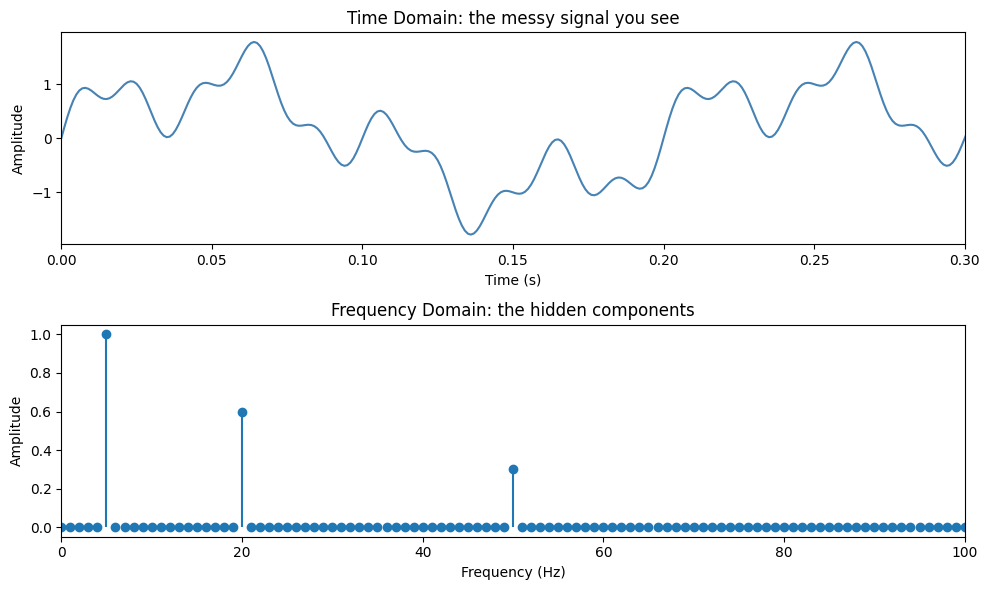

检测到的主要频率成分：
  频率     5 Hz  ->  振幅 1.00
  频率    20 Hz  ->  振幅 0.60
  频率    50 Hz  ->  振幅 0.30


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ========== 1. 构造一个复杂信号 ==========
# 采样参数
fs = 1000          # 采样率：每秒 1000 个点
t = np.arange(0, 1, 1/fs)   # 时间轴：1 秒，共 1000 个点

# 用三个不同频率的正弦波叠加成一个复杂信号
# 注意：这三个频率就是信号里"藏"着的成分
f1, f2, f3 = 5, 20, 50        # 频率：5Hz, 20Hz, 50Hz
A1, A2, A3 = 1.0, 0.6, 0.3    # 振幅：依次减弱

signal = (A1 * np.sin(2*np.pi*f1*t) +
          A2 * np.sin(2*np.pi*f2*t) +
          A3 * np.sin(2*np.pi*f3*t))

# ========== 2. 做傅里叶变换 ==========
N = len(signal)
fft_result = np.fft.fft(signal)          # 复数结果
freqs = np.fft.fftfreq(N, 1/fs)          # 每个点对应的频率

# 只取正频率部分（负频率是对称的，物理上只看正的一半）
mask = freqs >= 0
freqs_pos = freqs[mask]
amplitude = np.abs(fft_result)[mask] / N * 2   # 归一化，还原真实振幅

# ========== 3. 绘图对比 ==========
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

# 时域图：你看到的复杂波形
axes[0].plot(t, signal, color='steelblue')
axes[0].set_title('Time Domain: the messy signal you see')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].set_xlim(0, 0.3)   # 只看前 0.3 秒，避免太密

# 频域图：傅里叶变换揭示的"成分清单"
axes[1].stem(freqs_pos, amplitude, basefmt=" ")
axes[1].set_title('Frequency Domain: the hidden components')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.savefig('fourier_demo.png', dpi=120)
plt.show()

# ========== 4. 打印峰值 ==========
print("检测到的主要频率成分：")
for f, a in zip(freqs_pos, amplitude):
    if a > 0.1:   # 只打印明显的峰值
        print(f"  频率 {f:5.0f} Hz  ->  振幅 {a:.2f}")

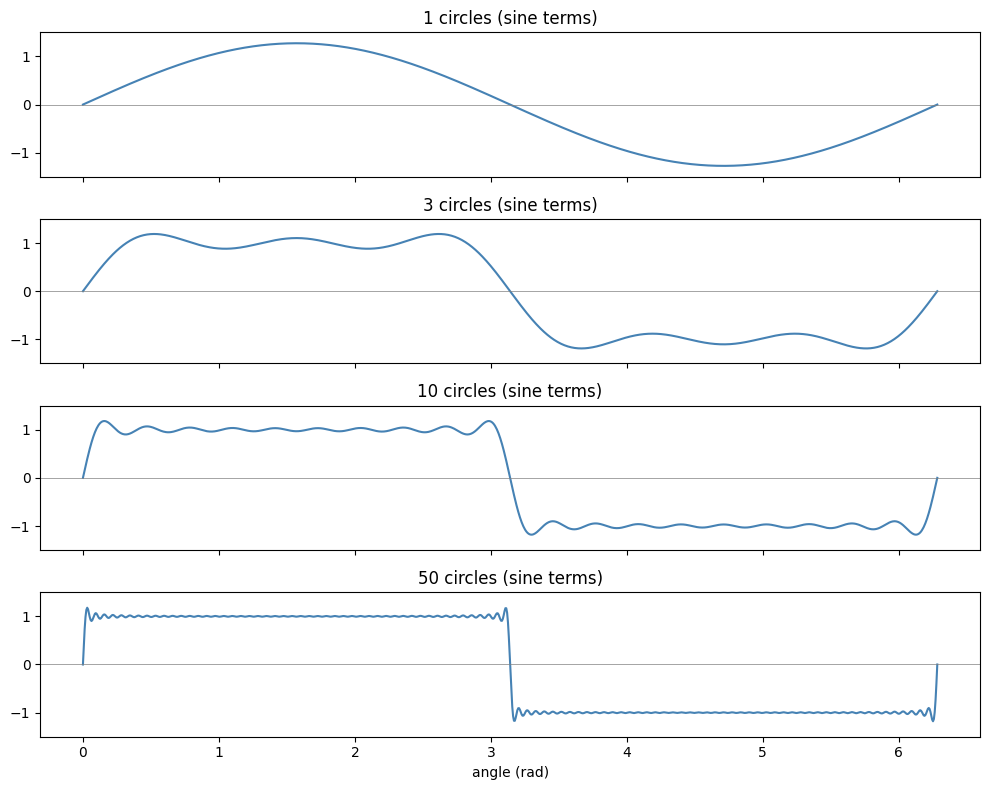

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 时间轴
t = np.linspace(0, 2*np.pi, 1000)

# 用多个圆（正弦波）叠加逼近方波
# 方波的傅里叶级数：sin(x) + sin(3x)/3 + sin(5x)/5 + sin(7x)/7 + ...
def square_wave_approx(t, n_terms):
    result = np.zeros_like(t)
    for k in range(n_terms):
        n = 2*k + 1          # 只取奇数频率：1, 3, 5, 7...
        result += np.sin(n*t) / n
    return result * 4 / np.pi   # 归一化，让振幅接近 1

# 画不同项数的逼近效果
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
terms_list = [1, 3, 10, 50]

for ax, n in zip(axes, terms_list):
    y = square_wave_approx(t, n)
    ax.plot(t, y, color='steelblue')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_title(f'{n} circles (sine terms)')
    ax.set_ylim(-1.5, 1.5)

axes[-1].set_xlabel('angle (rad)')
plt.tight_layout()
plt.savefig('fourier_circles.png', dpi=120)
plt.show()

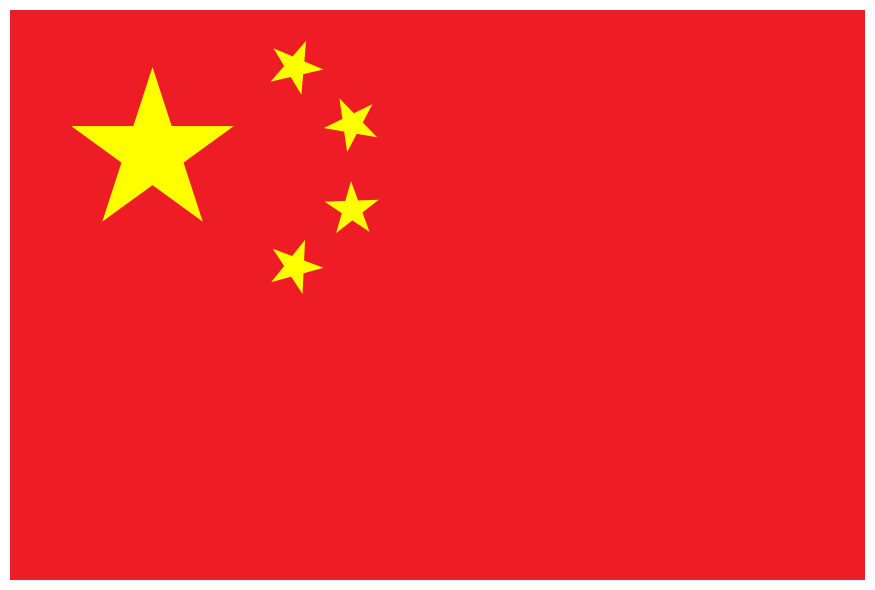

已生成：china_flag_precise.png / china_flag_precise.svg
大星中心: (0.2500, 0.7500)
小星中心: [(0.5, 0.9), (0.6, 0.8), (0.6, 0.65), (0.5, 0.55)]


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# ========== 0. 色值选择 ==========
COLOR_RED    = '#EE1C25'   # 国旗红 RGB(238,28,37)
COLOR_YELLOW = '#FFFF00'   # 五星黄 RGB(255,255,0)

# 如需切换为另一套参考色，取消下面两行注释
# COLOR_RED    = '#DE2910'
# COLOR_YELLOW = '#FFDE00'

# ========== 1. 基本参数 ==========
H = 1.0                 # 旗高（基准单位）
W = 1.5 * H             # 旗宽，长宽比 3:2

big_star_r   = (3/10 * H) / 2   # 大星外接圆半径 = 旗高 3/10 的一半
small_star_r = (1/10 * H) / 2   # 小星外接圆半径 = 旗高 1/10 的一半

# ========== 2. 网格基准（关键修正） ==========
# 国标：将"左上方长方形"上下划 10 等分、左右划 15 等分
# 这个长方形宽 = W/2，高 = H/2
half_w = W / 2
half_h = H / 2

grid_w = half_w / 15   # 每格宽 = (1.5H/2)/15 = H/20
grid_h = half_h / 10   # 每格高 = (H/2)/10   = H/20

# ========== 3. 五角星顶点计算 ==========
def star_vertices(cx, cy, r, rotation=0):
    """
    返回五角星的 10 个顶点坐标 (10,2)。
    cx, cy   : 中心
    r        : 外接圆半径
    rotation : 整体旋转角（弧度），0 表示第一个外角朝正上方
    """
    inner_r = r * np.sin(np.pi/10) / np.sin(3*np.pi/10)  # ≈ 0.382 r
    pts = []
    for i in range(5):
        a_out = np.pi/2 + rotation + i * 2*np.pi/5
        pts.append([cx + r*np.cos(a_out), cy + r*np.sin(a_out)])
        a_in = a_out + np.pi/5
        pts.append([cx + inner_r*np.cos(a_in), cy + inner_r*np.sin(a_in)])
    return np.array(pts)

# ========== 4. 五颗星的位置 ==========
# 大星中心：距左边 5 格、距上边 5 格
big_cx = 5 * grid_w
big_cy = H - 5 * grid_h    # 换算成从底边算的 y 坐标

# 四颗小星中心（x 从左边算，y 从底边算）
# 上2下8、左10右5 → (10格, 上2格)
# 上4下6、左12右3 → (12格, 上4格)
# 上7下3、左12右3 → (12格, 上7格)
# 上9下1、左10右5 → (10格, 上9格)
small_centers = [
    (10 * grid_w, H - 2 * grid_h),
    (12 * grid_w, H - 4 * grid_h),
    (12 * grid_w, H - 7 * grid_h),
    (10 * grid_w, H - 9 * grid_h),
]

# ========== 5. 绘图 ==========
fig, ax = plt.subplots(figsize=(9, 6))

# 旗面（红色）
ax.add_patch(Polygon([[0,0],[W,0],[W,H],[0,H]], closed=True,
                     facecolor=COLOR_RED, edgecolor='none'))

# 大星（黄色）
big_star = star_vertices(big_cx, big_cy, big_star_r, rotation=0)
ax.add_patch(Polygon(big_star, closed=True,
                     facecolor=COLOR_YELLOW, edgecolor='none'))

# 四颗小星：各有一个角尖指向大星中心
for (cx, cy) in small_centers:
    ang = np.arctan2(big_cy - cy, big_cx - cx)  # 指向大星中心的角度
    rot = ang - np.pi/2                          # 让第一个外角对准该方向
    star = star_vertices(cx, cy, small_star_r, rotation=rot)
    ax.add_patch(Polygon(star, closed=True,
                         facecolor=COLOR_YELLOW, edgecolor='none'))

# 坐标轴设置
ax.set_xlim(0, W)
ax.set_ylim(0, H)
ax.set_aspect('equal')
ax.axis('off')

# ========== 6. 输出 ==========
plt.tight_layout()

plt.savefig('china_flag_precise.png', dpi=300,
            bbox_inches='tight', pad_inches=0)

plt.savefig('china_flag_precise.svg',
            bbox_inches='tight', pad_inches=0)

plt.show()

print("已生成：china_flag_precise.png / china_flag_precise.svg")
print(f"大星中心: ({big_cx:.4f}, {big_cy:.4f})")
print(f"小星中心: {[(round(x,4), round(y,4)) for x,y in small_centers]}")